# Phase 1: DATA PIPELINE & EXPLORATORY DATA ANALYSIS (EDA)
**Objective:** Load raw data, perform initial exploratory data analysis, generate mock data for prototyping, and establish the PyTorch DataLoader pipeline.

## 1. Import Libraries & Setup Directories

## 2. Load Raw Data & Extract Mock Data
Generate a small random subset (5,000 samples) to unblock the Modeling team for training loop construction.

In [11]:
# 1. Import Libraries & Setup Directories
import os
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# Create directory structure if it doesn't exist
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True) 
print("Directories setup completed.")

# 2. Load Raw Data & Extract Mock Data 
print("Loading local Parquet file (GoEmotions)...") 
df_raw = pd.read_parquet(r"C:\nlp_project\data\raw\train-00000-of-00001.parquet") 

# Print actual columns for transparency
print(f"[DEBUG] Available columns in the dataset: {df_raw.columns.tolist()}")

# Define the 28 target emotion columns explicitly
EMOTION_COLUMNS = [
    "admiration", "amusement", "anger", "annoyance", "approval", 
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief", "remorse",
    "sadness", "surprise", "neutral"
]

print("Extracting text and one-hot encoded emotion columns...")
# Keep only the 'text' column and the 28 emotion columns (drop metadata like 'author', 'subreddit')
columns_to_keep = ['text'] + EMOTION_COLUMNS
df_full = df_raw[columns_to_keep].copy()

# Randomly sample 5,000 rows for the Modeling team
df_mock = df_full.sample(n=5000, random_state=42)

# Save the mock dataset to a separate CSV file
df_mock.to_csv(r"C:\nlp_project\data\raw\mock_data_goemotions.csv", index=False)  

print(f"Mock dataset successfully generated with {len(df_mock)} rows and {len(EMOTION_COLUMNS)} target classes.") 

Directories setup completed.
Loading local Parquet file (GoEmotions)...
[DEBUG] Available columns in the dataset: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Extracting text and one-hot encoded emotion columns...
Mock dataset successfully generated with 5000 rows and 28 target classes.


## 3. Exploratory Data Analysis (EDA)
Perform a comprehensive diagnostic of the raw dataset without altering its structural integrity. The objective is to identify data quality issues, class imbalances, and sequence length outliers to inform the downstream preprocessing and modeling strategies.

### 3.1. Data Check
Diagnose the presence of missing values and duplicate records. No removal actions are taken in this phase.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud 

# Set global plotting style
sns.set_theme(style="whitegrid")

print("--- Data Health Diagnostics ---")
# Count missing values specifically in the 'text' column
missing_values = df_full['text'].isnull().sum() 
print(f"Missing text rows: {missing_values}\n")

# Count exact duplicate texts across the dataframe
# In NLP, checking duplicate texts is more crucial than whole rows
duplicate_count = df_full['text'].duplicated().sum()
print(f"Total duplicate texts detected: {duplicate_count}")
print("Note: Duplicates and missing values will be handled in the Preprocessing pipeline.")

--- Data Health Diagnostics ---
Missing text rows: 0

Total duplicate texts detected: 153493
Note: Duplicates and missing values will be handled in the Preprocessing pipeline.


### 3.2. Label Distribution Analysis
Visualize the emotion class distribution to assess potential dataset imbalance, which may require techniques like class weighting during the model training phase.

C:\Users\trann\AppData\Local\Temp\ipykernel_4796\1410655005.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


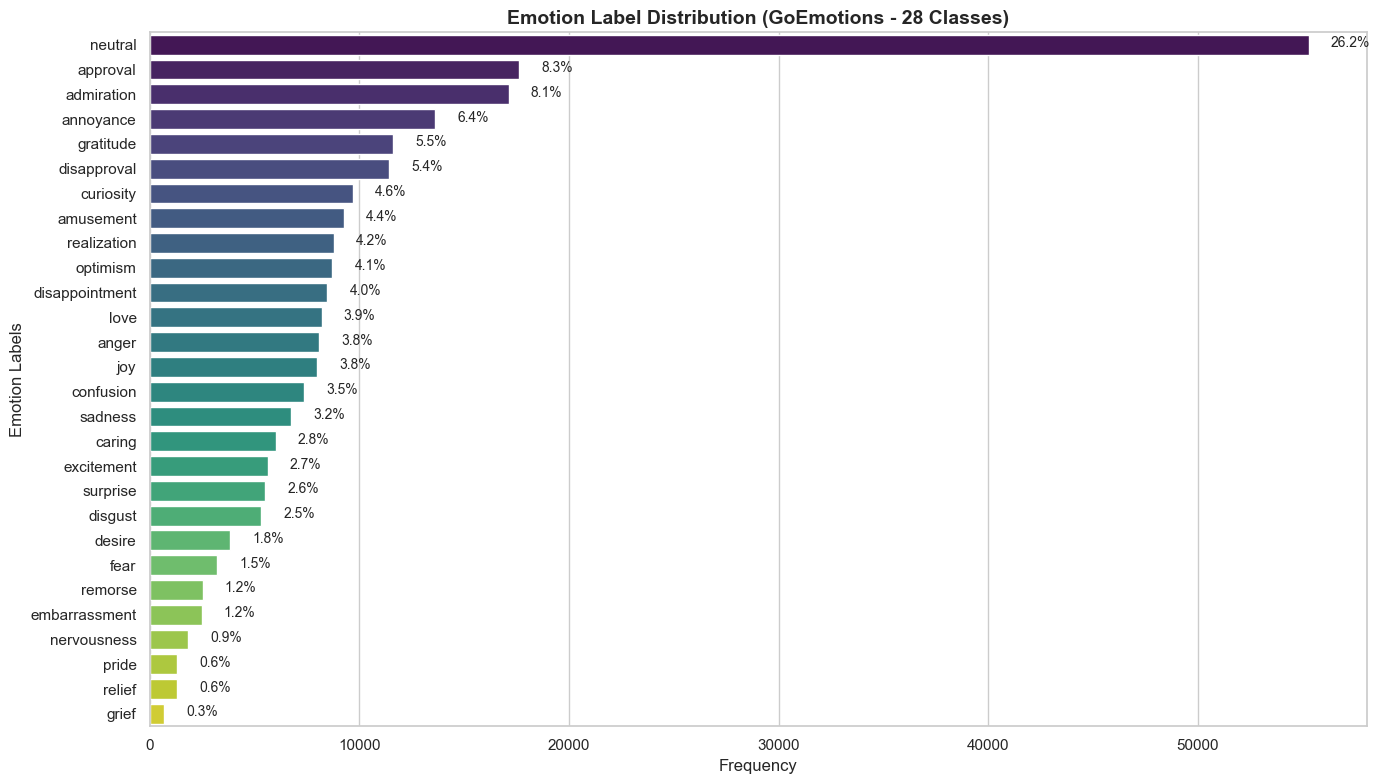

Insights: On average, each text sequence contains 1.18 emotion labels.


In [13]:
plt.figure(figsize=(14, 8))

# Sum the occurrences of each of the 28 emotion columns
label_counts = df_full[EMOTION_COLUMNS].sum().sort_values(ascending=False)

# Plot using a horizontal bar chart to accommodate 28 labels cleanly
ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.title('Emotion Label Distribution (GoEmotions - 28 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Emotion Labels', fontsize=12)

# Add percentage annotations to the right of each bar
total_sentences = len(df_full)
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total_sentences:.1f}%' 
    x = p.get_width() + (total_sentences * 0.005) # Slight offset to the right
    y = p.get_y() + p.get_height() / 2 + 0.1      # Center vertically
    ax.annotate(percentage, (x, y), size=10)

plt.tight_layout()
plt.show() 

# MULTI-LABEL INSIGHT: Calculate the average number of labels per sequence
labels_per_text = df_full[EMOTION_COLUMNS].sum(axis=1)
print(f"Insights: On average, each text sequence contains {labels_per_text.mean():.2f} emotion labels.") 

### 3.3. Text Sequence Length & Outlier Analysis
Calculate the word count for each text sequence to determine the optimal `max_length` parameter for tokenization (e.g., BERT or LSTM padding/truncation).

--- Text Length Statistics ---
count    211225.000000
mean         12.997188
std           6.676105
min           1.000000
25%           7.000000
50%          13.000000
75%          18.000000
max          33.000000
Name: word_count, dtype: float64


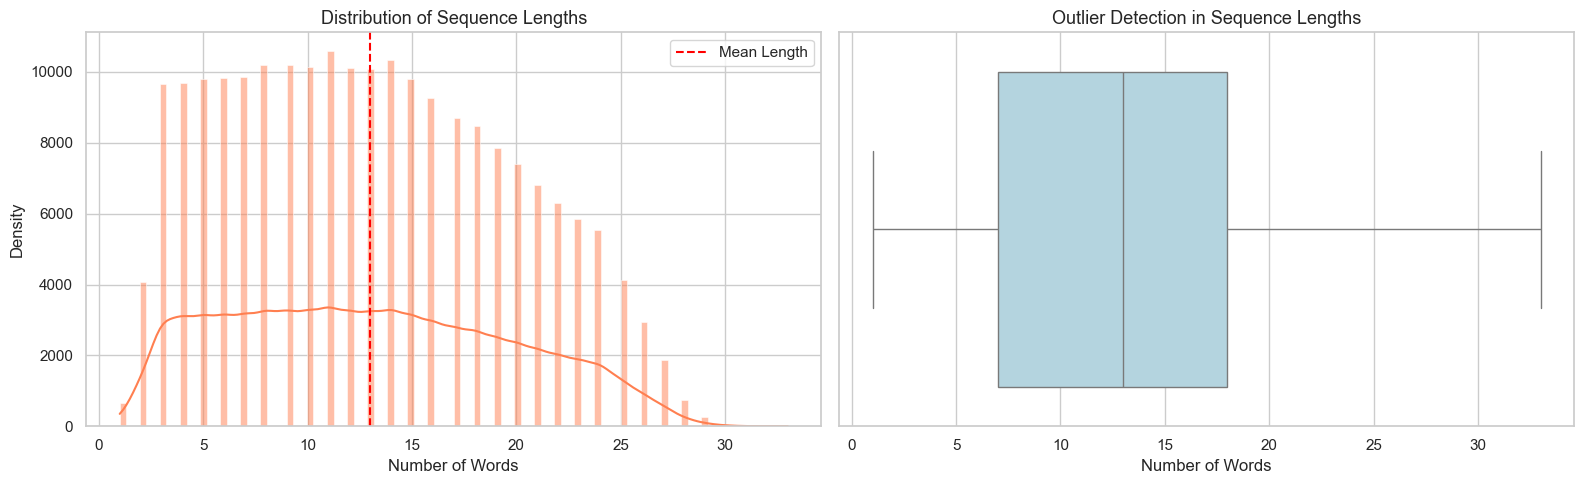

In [14]:
# Calculate sequence length (word count) for each row using the updated dataframe
df_full['word_count'] = df_full['text'].apply(lambda x: len(str(x).split()))

# Display descriptive statistics to identify outliers
print("--- Text Length Statistics ---")
print(df_full['word_count'].describe())

# Plot the distribution and outliers using a Histogram and a Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram for distribution
sns.histplot(df_full['word_count'], bins=100, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Distribution of Sequence Lengths', fontsize=13) 
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Density')
axes[0].axvline(df_full['word_count'].mean(), color='red', linestyle='--', label='Mean Length')
axes[0].legend()

# Boxplot for outlier detection
sns.boxplot(x=df_full['word_count'], color='lightblue', ax=axes[1])
axes[1].set_title('Outlier Detection in Sequence Lengths', fontsize=13)
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.show()

### 3.4. Linguistic Insights (Word Cloud)
Extract visual context from the text corpus. We isolate specific classes to observe the most frequently used vocabulary associated with distinct emotion labels.

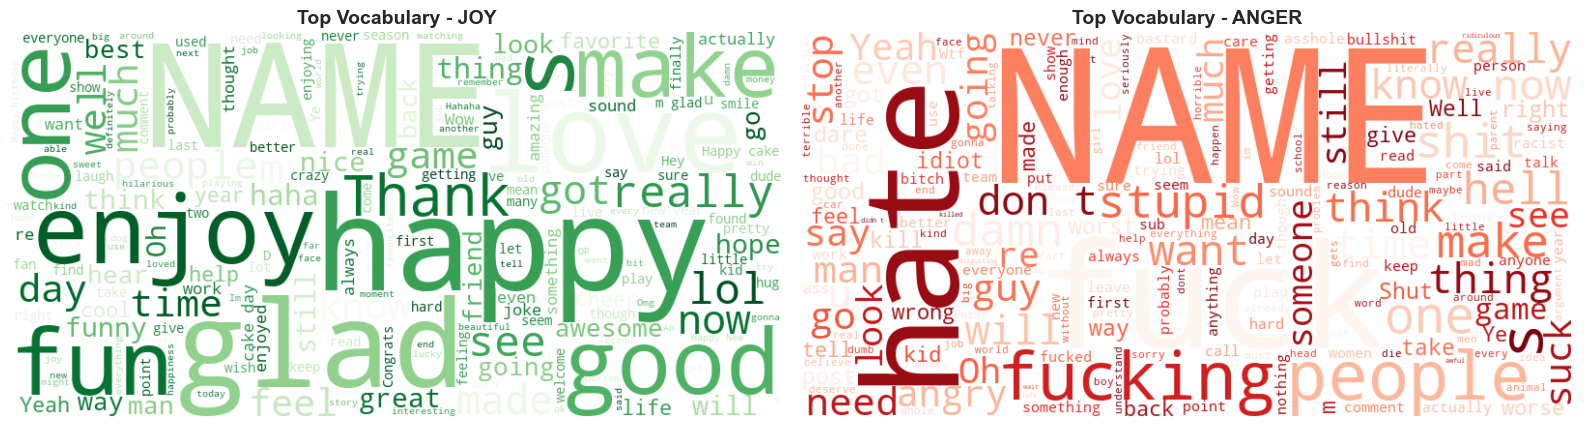

In [15]:
# Create a temporary subset without null texts specifically for visualization purposes
df_vis = df_full.dropna(subset=['text'])

# Select two contrasting labels for comparison using the new one-hot columns
# Let's compare 'joy' vs 'anger'
text_joy = " ".join(df_vis[df_vis['joy'] == 1]['text'].astype(str))
text_anger = " ".join(df_vis[df_vis['anger'] == 1]['text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generate Word Cloud for Joy
wordcloud_joy = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_joy)
axes[0].imshow(wordcloud_joy, interpolation='bilinear')
axes[0].set_title('Top Vocabulary - JOY', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Generate Word Cloud for Anger
wordcloud_anger = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_anger)
axes[1].imshow(wordcloud_anger, interpolation='bilinear')
axes[1].set_title('Top Vocabulary - ANGER', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show() 

## 4. Execute Modular Data Pipeline & Verify DataLoader
Import the refactored `DataPipelineManager` from our custom `data_pipeline` module. This step demonstrates the separation of concerns: the core pipeline logic is encapsulated in the source code (`.py`), while this notebook serves as the execution and verification environment.

In [16]:
# 4. Execute Modular Data Pipeline & Verify DataLoader

# Import the encapsulated pipeline classes from the local module
from data_pipeline import DataPipelineManager

# Initialize the pipeline manager with the respective file paths
pipeline = DataPipelineManager(
    raw_data_path=r"C:\nlp_project\data\raw\train-00000-of-00001.parquet", 
    mock_data_output_path=r"C:\nlp_project\data\raw\mock_data_goemotions.csv"
)

# Execute the mock data generation method (Extract 5000 rows for modeling team)
df_mock = pipeline.generate_mock_data()

# Construct the PyTorch DataLoader using the generated mock dataframe
# Batch size is set to 32
mock_loader = pipeline.get_pytorch_loaders(df_mock, batch_size=32)

# Extract a single batch to verify tensor shapes and pipeline integrity
sample_texts, sample_labels = next(iter(mock_loader))

print("DATALOADER VERIFICATION SUCCESSFUL!") 
print("-" * 50)
print(f"Batch text shape (Tuple length): {len(sample_texts)}")
print(f"Batch label shape (Tensor size): {sample_labels.shape}") 
print(f"Data type of labels: {sample_labels.dtype}")

DATALOADER VERIFICATION SUCCESSFUL!
--------------------------------------------------
Batch text shape (Tuple length): 32
Batch label shape (Tensor size): torch.Size([32, 28])
Data type of labels: torch.float32
